# NB2.1. Models of Networks

## A. Models of Networks.

Consider the following [Graph Generators](https://networkx.github.io/documentation/stable/reference/generators.html):

**Random Network Model**: The function ```erdos_renyi_graph(n,p)``` returns a $G_n,p$ random graph with the following parameters:
* n - The number of nodes.
* p - Probability fo edge creation.

**Small World Model ** : The function ```watts_strogatz_graph(n,k,p)``` returns a small-world graph with the following parameters:
* n - The number of nodes.
* k - Each node is joined with its k nearest neighbors in a ring topology.
* p - The probability of rewiring each edge.

### Task 1

Simulate different networks using the Erdos-Renyi Model considering the following parameters:

(a) N = 100, p = 0.20

(b) N = 100, p = 0.40

(c) N = 100, p = 0.60

(d) N = 100, p = 0.80

For each network plot its degree distribution. Additionally, make a comparative table including:
* Number of links.
* Expected number of links using the equation:
$$ \langle L \rangle = p \frac{N(N-1)}{2}$$
* Average degree.
* Expected average degrees using the equation:
$$\langle k \rangle = p(N-1)$$
* Density.
* Expected density using the equation:
$$\langle d \rangle = p$$
* Average Shortest Path.
* Expected Average Shortest Path using the equation:
$$\langle l \rangle \approx \frac{ln(N)}{ln(\langle k \rangle)}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
base_dir = Path(".")

def average_shortest_path(G):
    if G.number_of_nodes() < 2:
        return 0
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    giant_nodes = max(nx.connected_components(G), key=len)
    giant = G.subgraph(giant_nodes).copy()
    if giant.number_of_nodes() < 2:
        return 0
    return nx.average_shortest_path_length(giant)

def expected_shortest_path(N, p):
    k = p * (N - 1)
    if k <= 1:
        return np.nan
    return np.log(N) / np.log(k)

def graph_summary(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / n
    giant_nodes = max(nx.connected_components(G), key=len)
    return {
        "nodes": n,
        "links": m,
        "avg_degree": avg_degree,
        "density": nx.density(G),
        "clustering": nx.average_clustering(G),
        "avg_shortest_path": average_shortest_path(G),
        "giant_component_ratio": len(giant_nodes) / n,
    }

def read_model(filename):
    df = pd.read_csv(base_dir / filename, header=None)
    return nx.from_pandas_adjacency(df)

def plot_degree_distribution(ax, G, title):
    degrees = [degree for _, degree in G.degree()]
    bins = range(min(degrees), max(degrees) + 2)
    ax.hist(degrees, bins=bins, color="#4C78A8", edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency")

def analyze_model(filename):
    G = read_model(filename)
    summary = graph_summary(G)
    degrees = [degree for _, degree in G.degree()]
    summary["min_degree"] = min(degrees)
    summary["max_degree"] = max(degrees)
    summary["components"] = nx.number_connected_components(G)
    return G, summary

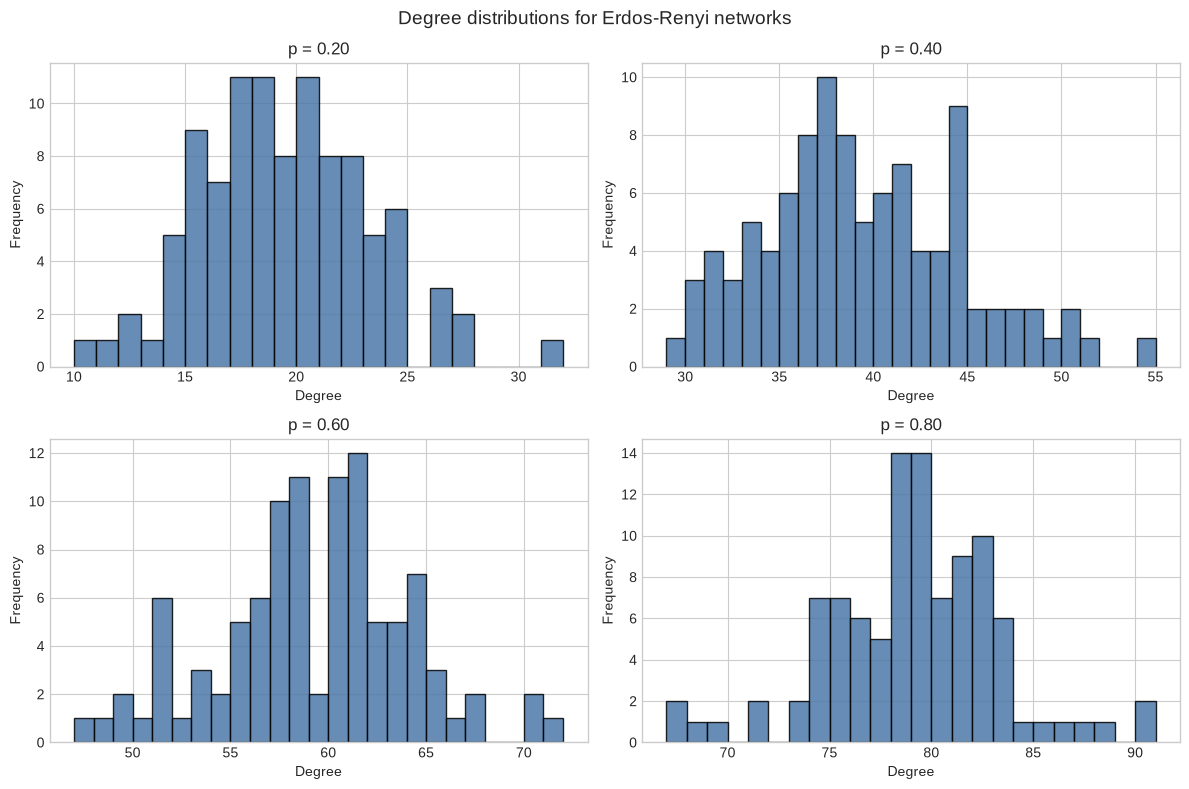

,links,expected_links,avg_degree,expected_avg_degree,density,expected_density,avg_shortest_path,expected_avg_shortest_path
p,,,,,,,,
0.2,949,990.0,18.98,19.8,0.192,0.2,1.828,1.542
0.4,1948,1980.0,38.96,39.6,0.394,0.4,1.606,1.252
0.6,2938,2970.0,58.76,59.4,0.594,0.6,1.406,1.128
0.8,3929,3960.0,78.58,79.2,0.794,0.8,1.206,1.053


In [2]:
N = 100
probabilities = [0.20, 0.40, 0.60, 0.80]
results = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Degree distributions for Erdos-Renyi networks", fontsize=14)

for ax, p in zip(axes.ravel(), probabilities):
    G = nx.fast_gnp_random_graph(N, p, seed=42)
    
    summary = graph_summary(G)
    results.append({
        "p": p,
        "links": summary["links"],
        "expected_links": p * N * (N - 1) / 2,
        "avg_degree": summary["avg_degree"],
        "expected_avg_degree": p * (N - 1),
        "density": summary["density"],
        "expected_density": p,
        "avg_shortest_path": summary["avg_shortest_path"],
        "expected_avg_shortest_path": expected_shortest_path(N, p),
    })
    plot_degree_distribution(ax, G, f"p = {p:.2f}")

plt.tight_layout()
plt.show()

comparison = pd.DataFrame(results).set_index("p").round(3)
comparison

### Task 2

Consider a the simulation of different random network with a fixed value of the number of nodes but different values of link probability. Naturally, at the beginig at p = 0, the system is totally fragmented into singletons. An increasing number of pairs of nodes will get connected, and through them connected subnetworks will be formed as the link probability increases. 

Erdos and Renyi discovered a transition point from configurations in which all subnetworks are relatively small, to a configuration where at least one of the subnetworks contains almost all the nodes. This transition can be observe in Fig. 1. 




<img src="Plot1.png" width="360"> </img>

<center> Fig. 2</center>


Don't forget that the probability and the expected degree $\langle k \rangle$  follow the relation:

$$ \langle L \rangle = p \frac{N(N-1)}{2}$$

Fig. 1 is an sketch of the evoluation. Reproduce a similar plot for networks with 1000 nodes. Use 25 equally spaced values of the link probability, in the interval [0, 0.005]. For each value, generate 20 different networks, compute the relative size of the giant component. 

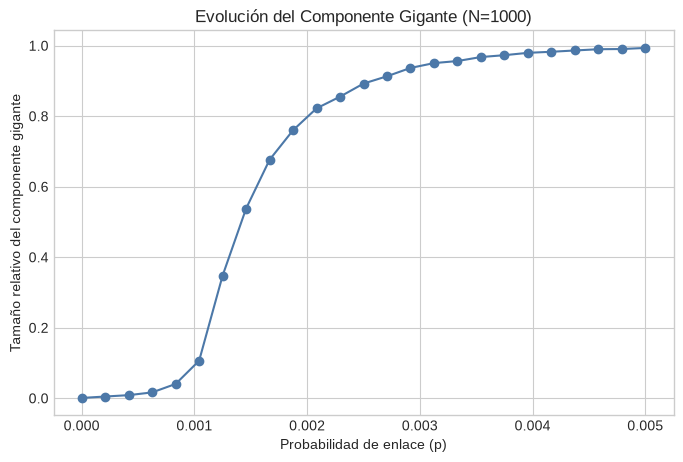

In [3]:
N_task2 = 1000
p_values = np.linspace(0, 0.005, 25) 
num_networks = 20

giant_component_ratios = []

for p in p_values:
    ratios_for_p = []
    for _ in range(num_networks):
        G = nx.fast_gnp_random_graph(N_task2, p)
        
        if G.number_of_nodes() > 0:
            giant_nodes = max(nx.connected_components(G), key=len)
            ratio = len(giant_nodes) / N_task2
        else:
            ratio = 0
            
        ratios_for_p.append(ratio)
        
    giant_component_ratios.append(np.mean(ratios_for_p))

plt.figure(figsize=(8, 5))
plt.plot(p_values, giant_component_ratios, marker='o', color="#4C78A8")
plt.title("Evolución del Componente Gigante (N=1000)")
plt.xlabel("Probabilidad de enlace (p)")
plt.ylabel("Tamaño relativo del componente gigante")
plt.show()

### Task 3
In the Watts-Strogratz Model, there is range of rewiring probability values between p = 0.01 and p = 0.1 in the average shortest-path length is close to that of an equivalent random network; and at the same time, the clustering coefficient from the model is high. Nevertheless, the model cannot generate hubs. Fig. 2 presents the average path length and the clustering coefficient as a function of the rewiring probability. Observe that the x-axis is in a logarithmic scale.


<img src="Plot2.png" width="360"> </img>

<center> Fig. 2</center>


Reproduce a similar plot, by calculating:
* the average shortest path ($\langle l \rangle$)
* and the average clustering coefficient ($C$)

for Watts–Strogatz networks constructed for different values of the rewiring probability p. Take 20 equally spaced values of p between 0 and 1. For each value of p, build 20 different networks and compute the average shortest path and average clustering coefficient. To plot the two curves on a common y-axis, you can normalize the values by dividing them by the corresponding values for the probability p = 0.

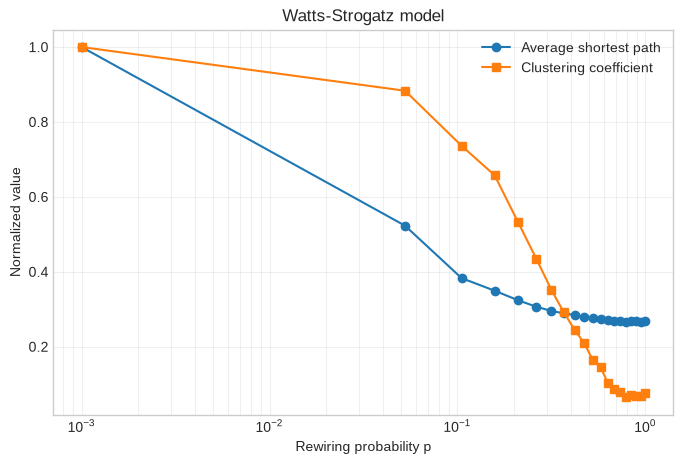

,p,avg_path,clustering
0,0.0000,12.8788,0.5000
1,0.0526,6.7368,0.4417
2,0.1053,4.9339,0.3682
3,0.1579,4.5009,0.3288
4,0.2105,4.1708,0.2661
5,0.2632,3.9499,0.2174
6,0.3158,3.8064,0.1763
7,0.3684,3.7241,0.1459
8,0.4211,3.6597,0.1225
9,0.4737,3.5954,0.1045


In [4]:
n = 100
k = 4
p_values = np.linspace(0, 1, 20)
avg_paths = []
avg_clustering = []

for p in p_values:
    paths = []
    clustering = []
    for run in range(20):
        G = nx.watts_strogatz_graph(n, k, p, seed=2000 + run + int(p * 1000))
        paths.append(average_shortest_path(G))
        clustering.append(nx.average_clustering(G))
    avg_paths.append(np.mean(paths))
    avg_clustering.append(np.mean(clustering))

base_path = avg_paths[0]
base_clustering = avg_clustering[0]
normalized_paths = [value / base_path for value in avg_paths]
normalized_clustering = [value / base_clustering for value in avg_clustering]
p_plot = np.where(p_values == 0, 1e-3, p_values)

plt.figure(figsize=(8, 5))
plt.semilogx(p_plot, normalized_paths, "o-", label="Average shortest path")
plt.semilogx(p_plot, normalized_clustering, "s-", label="Clustering coefficient")
plt.xlabel("Rewiring probability p")
plt.ylabel("Normalized value")
plt.title("Watts-Strogatz model")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

pd.DataFrame({"p": p_values, "avg_path": avg_paths, "clustering": avg_clustering}).round(4)

## B. Identification of Network Models [40 pts]

### Task 4
Analyze each of the 4 Networks and determine which of the three models was used to generate them:
* model1.csv
* model2.csv
* model3.csv
* model4.csv

In [5]:
G1, s1 = analyze_model("model1.csv")
print("model1.csv looks like an Erdos-Renyi random network.")
print(f"Nodes = {s1['nodes']}, links = {s1['links']}, density = {s1['density']:.4f}, clustering = {s1['clustering']:.4f}")
print(f"Components = {s1['components']}, giant component ratio = {s1['giant_component_ratio']:.2f}, degree range = {s1['min_degree']} to {s1['max_degree']}")
print("The degree values are pretty concentrated and the clustering is basically zero, so it behaves like a sparse random graph.")

model1.csv looks like an Erdos-Renyi random network.
Nodes = 100, links = 100, density = 0.0202, clustering = 0.0000
Components = 2, giant component ratio = 0.92, degree range = 1 to 4
The degree values are pretty concentrated and the clustering is basically zero, so it behaves like a sparse random graph.


In [6]:
G2, s2 = analyze_model("model2.csv")
print("model2.csv also looks like an Erdos-Renyi random network.")
print(f"Nodes = {s2['nodes']}, links = {s2['links']}, density = {s2['density']:.4f}, clustering = {s2['clustering']:.4f}")
print(f"Components = {s2['components']}, giant component ratio = {s2['giant_component_ratio']:.2f}, degree range = {s2['min_degree']} to {s2['max_degree']}")
print("This one is denser than model1, but the degree spread still looks random instead of hub-based.")

model2.csv also looks like an Erdos-Renyi random network.
Nodes = 100, links = 738, density = 0.1491, clustering = 0.1503
Components = 1, giant component ratio = 1.00, degree range = 8 to 25
This one is denser than model1, but the degree spread still looks random instead of hub-based.


In [7]:
G3, s3 = analyze_model("model3.csv")
print("model3.csv looks like a Watts-Strogatz small-world network.")
print(f"Nodes = {s3['nodes']}, links = {s3['links']}, density = {s3['density']:.4f}, clustering = {s3['clustering']:.4f}")
print(f"Components = {s3['components']}, giant component ratio = {s3['giant_component_ratio']:.2f}, degree range = {s3['min_degree']} to {s3['max_degree']}")
print("The clustering is high and the average path is short, which is the small-world pattern. The degree sequence is not perfectly regular because of rewiring.")

model3.csv looks like a Watts-Strogatz small-world network.
Nodes = 60, links = 800, density = 0.4520, clustering = 0.8132
Components = 1, giant component ratio = 1.00, degree range = 8 to 59
The clustering is high and the average path is short, which is the small-world pattern. The degree sequence is not perfectly regular because of rewiring.


In [8]:
G4, s4 = analyze_model("model4.csv")
print("model4.csv also looks like a Watts-Strogatz small-world network, very close to the regular ring lattice case.")
print(f"Nodes = {s4['nodes']}, links = {s4['links']}, density = {s4['density']:.4f}, clustering = {s4['clustering']:.4f}")
print(f"Components = {s4['components']}, giant component ratio = {s4['giant_component_ratio']:.2f}, degree range = {s4['min_degree']} to {s4['max_degree']}")
print("Every node has degree 2, so this is the cleanest small-world example in the set.")

model4.csv also looks like a Watts-Strogatz small-world network, very close to the regular ring lattice case.
Nodes = 100, links = 100, density = 0.0202, clustering = 0.0000
Components = 1, giant component ratio = 1.00, degree range = 2 to 2
Every node has degree 2, so this is the cleanest small-world example in the set.


In [9]:
print("In short, model1 and model2 behave like random networks, while model3 and model4 behave like small-world networks.")

In short, model1 and model2 behave like random networks, while model3 and model4 behave like small-world networks.


## References
[1] F. Mencszer, S. Fortunato, C. A. Davis (2020). A First Course in Network Science.